# L15b: Build and Test Three-Gene Dynamics

This lab applies the explicit-Euler algorithm to an adapted three-gene production/degradation model from the 2024 course.

> **Learning objectives**
>
> - Translate production and degradation rules into a state derivative.
> - Verify one Euler step by hand.
> - Diagnose step-size sensitivity against a maintained solver.
> - Test dimensions, finite outputs, and physical nonnegativity.


## Setup


In [1]:
include(joinpath(@__DIR__, "Include.jl"))


## Model contract

The state is `x = [P1, P2, P3]`. Production uses saturating Hill functions and degradation is first order. The external activator drives `P1`; the network connections then regulate `P2` and `P3`.


In [2]:
parameters = three_gene_parameters()
initial_state = zeros(3)
initial_derivative = three_gene_rhs(initial_state, 0.0, parameters)
DataFrame(gene = ["P1", "P2", "P3"], initial_state = initial_state,
    initial_derivative = initial_derivative)


Row,gene,initial_state,initial_derivative
,String,Float64,Float64
1,P1,0.0,0.227273
2,P2,0.0,0.0
3,P3,0.0,0.0


## Verify the first explicit-Euler step


In [3]:
dt = 0.1
hand_step = initial_state .+ dt .* initial_derivative
one_step = explicit_euler(
    three_gene_rhs,
    initial_state,
    (0.0, dt),
    dt;
    p = parameters,
)
(hand_step = hand_step, implementation_step = vec(one_step.u[2, :]),
    agree = hand_step ≈ one_step.u[2, :])


(hand_step = [0.022727272727272728, 0.0, 0.0], implementation_step = [0.022727272727272728, 0.0, 0.0], agree = true)

## Step-size study


In [4]:
reference = library_integrate(
    three_gene_rhs,
    initial_state,
    (0.0, 60.0);
    p = parameters,
    saveat = 0.1,
)
step_sizes = [0.5, 0.2, 0.1]
runs = [
    explicit_euler(
        three_gene_rhs,
        initial_state,
        (0.0, 60.0),
        step;
        p = parameters,
    )
    for step in step_sizes
]
DataFrame(
    dt = step_sizes,
    final_state_error = [norm(run.u[end, :] - reference.u[end, :]) for run in runs],
    minimum_state = [minimum(run.u) for run in runs],
)


Row,dt,final_state_error,minimum_state
,Float64,Float64,Float64
1,0.5,0.100181,0.0
2,0.2,0.0396487,0.0
3,0.1,0.0197813,0.0


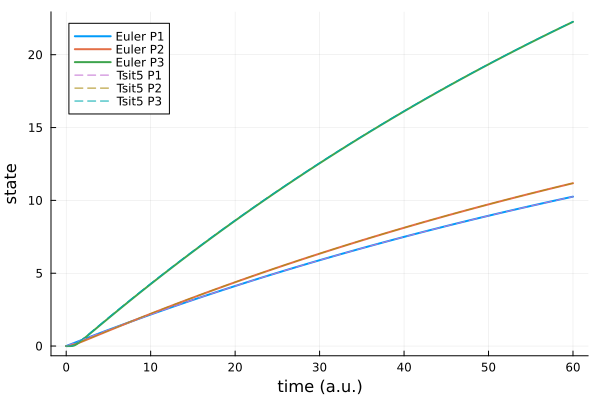

In [5]:
selected = last(runs)
plot(
    selected.t,
    selected.u;
    label = ["Euler P1" "Euler P2" "Euler P3"],
    linewidth = 2,
    xlabel = "time (a.u.)",
    ylabel = "state",
)
plot!(reference.t, reference.u; label = ["Tsit5 P1" "Tsit5 P2" "Tsit5 P3"],
    linestyle = :dash)


## Test the implementation contract


In [6]:
@testset "three-gene dynamics" begin
    @test hand_step ≈ one_step.u[2, :]
    @test all(isfinite, selected.u)
    @test minimum(selected.u) >= 0
    @test selected.u[end, 1] > 0
    @test norm(last(runs).u[end, :] - reference.u[end, :]) <=
        norm(first(runs).u[end, :] - reference.u[end, :])
    @test_throws DimensionMismatch three_gene_rhs(zeros(2), 0.0, parameters)
end


Test Summary:       | Pass  Total  Time
three-gene dynamics |    6      6  0.7s


Test.DefaultTestSet("three-gene dynamics", Any[], 6, false, false, true, 1.786458865523787e9, 1.786458866180106e9, false, "In[6]", Random.Xoshiro(0x2423a0824b44e430, 0xf0db960e1122c473, 0x18068a1ac8451b01, 0x184d3fca8ba99b07, 0x18f3d3bc39a9f5bf))

## Interpretation

Agreement with a library solver is evidence about the numerical implementation, not proof that the biological model is complete. The model still assumes fixed parameters, a constant activator, and a specific regulatory structure.
